# Cycle 7 : Approche finale


In [50]:
from technova_correlation_cleaning import CorrelationFilter
from technova_features import TechNovaFeatureEngineering
### Import des modules
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
data = pd.read_csv('data/rafined/employees.csv', sep=',')

In [52]:
train_data = utils.split_train_data(data, 'a_quitte_l_entreprise')

In [55]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scaler', RobustScaler(), ['revenu_mensuel']),
        ('minmax_scaler', MinMaxScaler(), ['age', 'distance_domicile_travail']),
        ('encoder', OneHotEncoder(handle_unknown='ignore'), ['statut_marital', 'departement', 'poste', 'domaine_etude']),
    ],
    remainder='passthrough'
)

In [71]:
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.pipeline import Pipeline

random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

threshold_model = FixedThresholdClassifier(
    estimator=random_forest_model,
    threshold=0.3,
    response_method="predict_proba"
)

pipeline = Pipeline([
    ('features', TechNovaFeatureEngineering()),
    ('corr_cleaning', CorrelationFilter(threshold=0.80)),
    ('preprocessor', preprocessor),
    ('model', threshold_model),
])

utils.benchmark(pipeline, train_data)

CrossValidation Results : 
{'fit_time': array([0.11890507, 0.11433983, 0.11106086, 0.113585  , 0.11311412]), 'score_time': array([0.0116868 , 0.012429  , 0.0118618 , 0.01225996, 0.0120151 ]), 'test_recall': array([0.8       , 0.71794872, 0.64102564, 0.725     , 0.875     ]), 'test_f1': array([0.5203252 , 0.51376147, 0.42735043, 0.46774194, 0.53846154])}
Recall moyen : 0.7517948717948718
F1-Score moyen : 0.49352811448755557
Training Résults : 
Recall moyen : 0.6410256410256411
F1-Score moyen : 0.4
[[194  61]
 [ 14  25]]


In [ ]:
utils.train(pipeline, train_data)

In [ ]:
features = pipeline['model'].estimator_.feature_importances_
names = preprocessor.get_feature_names_out()
utils.show_importances(features, names)

In [66]:
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'model__estimator__max_depth': [5, 8, 12, 15, None],
    'model__estimator__min_samples_split': [2, 5, 10],
    'model__estimator__min_samples_leaf': [2, 5, 10, 15],
    'model__estimator__n_estimators': [100, 200, 300]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(train_data['X_train'], train_data['y_train'])

print(f"Meilleurs paramètres : {search.best_params_}")
print(f"Recall validé en Cross-Validation : {search.best_score_:.4f}")

best_pipeline = search.best_estimator_

y_pred_best = best_pipeline.predict(train_data['X_test'])

recall_final = recall_score(train_data['y_test'], y_pred_best)
f1_final = f1_score(train_data['y_test'], y_pred_best)

print(f"Résultats Finaux sur le Test Set :")
print(f"Recall : {recall_final:.4f}")
print(f"F1-Score : {f1_final:.4f}")
print("Matrice de Confusion :\n", confusion_matrix(train_data['y_test'], y_pred_best))

Meilleurs paramètres : {'model__estimator__n_estimators': 100, 'model__estimator__min_samples_split': 10, 'model__estimator__min_samples_leaf': 5, 'model__estimator__max_depth': 5}
Recall validé en Cross-Validation : 0.9341
Résultats Finaux sur le Test Set :
Recall : 0.8462
F1-Score : 0.2672
Matrice de Confusion :
 [[ 80 175]
 [  6  33]]


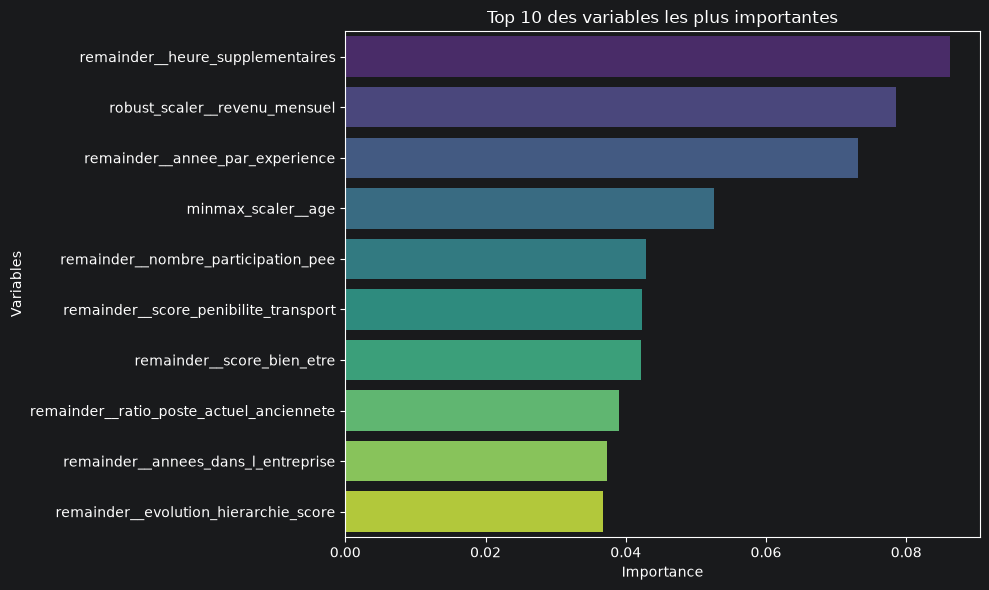

In [59]:
final_rf_model = best_pipeline.named_steps['model'].estimator_
features = final_rf_model.feature_importances_
names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

utils.show_importances(features, names)

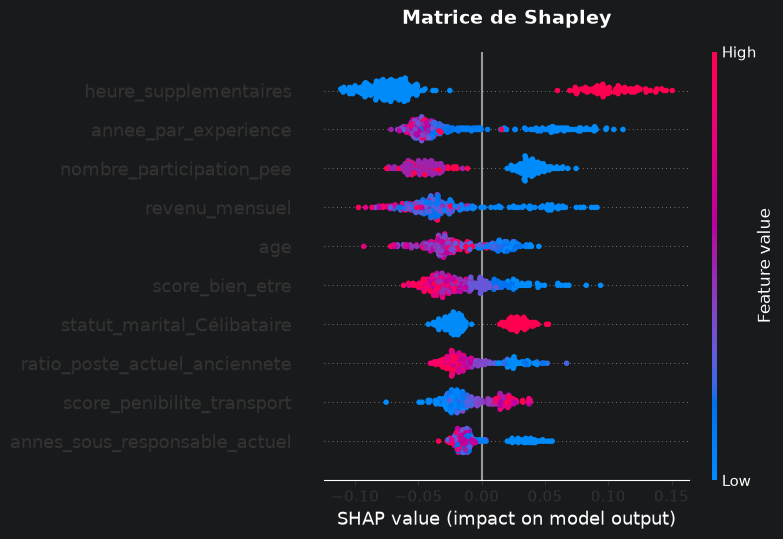

In [65]:
import shap

prep_pipeline = Pipeline(best_pipeline.steps[:-1])

feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_names = [
    name.replace('remainder__', '')
        .replace('encoder__', '')
        .replace('robust_scaler__', '')
        .replace('minmax_scaler__', '')
    for name in feature_names
]

X_test_shap = pd.DataFrame(prep_pipeline.transform(train_data['X_test']), columns=feature_names)

final_rf_model = best_pipeline.named_steps['model'].estimator_

explainer = shap.TreeExplainer(final_rf_model)

shap_values = explainer.shap_values(X_test_shap)

shap_values_target = shap_values[:, :, 1]

shap.summary_plot(
    shap_values_target,
    X_test_shap,
    max_display=10,
    plot_type="dot",
    show=False
)

plt.title("Matrice de Shapley", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()